# Notebook 3: Embeddings y Búsqueda Semántica con AWS Bedrock

En este notebook aprenderás a:
- Generar embeddings de texto con Amazon Titan Embeddings
- Entender qué es un embedding y cómo se representa
- Calcular similitud semántica entre textos
- Construir un buscador semántico con FAISS
- Comparar búsqueda semántica vs búsqueda por palabras clave

---

> **Requisito:** boto3 instalado y credenciales AWS configuradas.

## 1. Instalación de dependencias

In [ ]:
# !pip install boto3 faiss-cpu numpy --quiet

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
AWS_BEARER_TOKEN_BEDROCK=os.getenv("AWS_BEARER_TOKEN_BEDROCK")
AWS_ACCESS_KEY_ID=os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY=os.getenv("AWS_SECRET_ACCESS_KEY")
AWS_DEFAULT_REGION=os.getenv("AWS_DEFAULT_REGION")

# API key de Gemini
# API_KEY = userdata.get('GEMINI_API_KEY')

## 2. Setup del cliente

In [ ]:
import boto3
import json
import numpy as np
import faiss
import math

REGION            = AWS_DEFAULT_REGION
EMBEDDING_MODEL   = "amazon.titan-embed-text-v2:0"
GENERACION_MODEL  = "eu.anthropic.claude-haiku-4-5-20251001-v1:0"

bedrock_runtime = boto3.client(
    service_name="bedrock-runtime",
    region_name=REGION
)

print("✅ Cliente Bedrock listo")
print(f"   Modelo de embeddings : {EMBEDDING_MODEL}")
print(f"   Modelo de generación : {GENERACION_MODEL}")

✅ Cliente Bedrock listo
   Modelo de embeddings : amazon.titan-embed-text-v2:0
   Modelo de generación : eu.anthropic.claude-haiku-4-5-20251001-v1:0


## 3. ¿Qué es un Embedding?

Un **embedding** es una representación numérica (vector) de un texto que captura su significado semántico.

- Textos con significado similar → vectores cercanos en el espacio
- Textos con significado diferente → vectores lejanos
- Amazon Titan Embeddings genera vectores de **1536 dimensiones**

```
"El gato duerme"   → [0.12, -0.45, 0.78, ...] (1536 números)
"El felino reposa" → [0.11, -0.44, 0.79, ...] (muy cercano!)
"Receta de pizza"  → [0.89,  0.23, -0.54, ...] (muy lejano)
```

## 4. Generar el primer embedding

In [ ]:
def generar_embedding(texto: str) -> np.ndarray:
    """Genera un embedding para un texto usando Amazon Titan Embeddings."""
    body = {"inputText": texto}
    response = bedrock_runtime.invoke_model(
        modelId=EMBEDDING_MODEL,
        body=json.dumps(body),
        contentType="application/json",
        accept="application/json"
    )
    resultado = json.loads(response["body"].read())
    return np.array(resultado["embedding"], dtype=np.float32)


# Generar embedding de ejemplo
texto_ejemplo = "AWS Bedrock permite usar modelos de lenguaje en la nube."
embedding = generar_embedding(texto_ejemplo)

print(f"Texto: '{texto_ejemplo}'")
print(f"Dimensiones del vector: {embedding.shape}")
print(f"Primeros 10 valores   : {embedding[:10].round(4)}")
print(f"Norma del vector      : {np.linalg.norm(embedding):.4f}")

Texto: 'AWS Bedrock permite usar modelos de lenguaje en la nube.'
Dimensiones del vector: (1024,)
Primeros 10 valores   : [-0.1077  0.0416  0.0191 -0.0088  0.0231  0.0129  0.0682 -0.0513  0.0186
 -0.0426]
Norma del vector      : 1.0000


## 5. Similitud semántica con Cosine Similarity

La **similitud coseno** mide el ángulo entre dos vectores. Valor entre -1 y 1:
- **1.0** → idénticos
- **0.0** → sin relación
- **-1.0** → opuestos

In [ ]:
def similitud_coseno(v1: np.ndarray, v2: np.ndarray) -> float:
    """Calcula la similitud coseno entre dos vectores."""
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


# Texto de referencia
referencia = "El aprendizaje automático es una rama de la inteligencia artificial."

# Textos a comparar
candidatos = [
    "Machine learning es un subcampo de la IA.",
    "Los algoritmos de ML aprenden de los datos.",
    "La inteligencia artificial transforma los negocios.",
    "El fútbol es el deporte más popular del mundo.",
    "La receta de la paella valenciana lleva arroz y mariscos.",
]

emb_referencia = generar_embedding(referencia)

print(f"Referencia: '{referencia}'")
print("\nSimilitud con candidatos:")
print("-" * 70)

resultados = []
for texto in candidatos:
    emb = generar_embedding(texto)
    sim = similitud_coseno(emb_referencia, emb)
    resultados.append((sim, texto))

resultados.sort(reverse=True)
for sim, texto in resultados:
    barra = "█" * int(sim * 30)
    print(f"{sim:.4f} {barra:<30} {texto}")

Referencia: 'El aprendizaje automático es una rama de la inteligencia artificial.'

Similitud con candidatos:
----------------------------------------------------------------------
0.4267 ████████████                   Los algoritmos de ML aprenden de los datos.
0.3592 ██████████                     Machine learning es un subcampo de la IA.
0.3116 █████████                      La inteligencia artificial transforma los negocios.
0.0503 █                              La receta de la paella valenciana lleva arroz y mariscos.
0.0314                                El fútbol es el deporte más popular del mundo.


## 6. Construir un índice vectorial con FAISS

**FAISS** (Facebook AI Similarity Search) permite hacer búsquedas eficientes sobre millones de vectores. Es perfecto para prototipos locales antes de usar un servicio gestionado como OpenSearch o Pinecone.

In [ ]:
# Base de conocimiento: artículos sobre tecnología
documentos = [
    # Nube
    "AWS ofrece más de 200 servicios en la nube, desde cómputo hasta IA.",
    "Amazon S3 es un servicio de almacenamiento de objetos altamente escalable.",
    "EC2 permite lanzar servidores virtuales en cuestión de segundos.",
    "Lambda es el servicio de computación serverless de AWS.",
    # IA / ML
    "Los modelos de lenguaje grande (LLM) son la base de la IA generativa actual.",
    "AWS Bedrock facilita el acceso a modelos de IA sin gestionar infraestructura.",
    "Los embeddings representan texto como vectores numéricos para búsqueda semántica.",
    "SageMaker es la plataforma de machine learning gestionada de AWS.",
    # Bases de datos
    "RDS permite ejecutar bases de datos relacionales como PostgreSQL y MySQL en AWS.",
    "DynamoDB es una base de datos NoSQL totalmente gestionada y de baja latencia.",
    "Amazon Aurora es compatible con MySQL y PostgreSQL y es hasta 5x más rápida.",
    # Seguridad
    "IAM gestiona el acceso a recursos de AWS mediante roles, usuarios y políticas.",
    "AWS KMS permite crear y gestionar claves de cifrado de forma centralizada.",
    "AWS Shield protege contra ataques de denegación de servicio (DDoS).",
]

print(f"Total de documentos en la base de conocimiento: {len(documentos)}")

Total de documentos en la base de conocimiento: 14


In [ ]:
# Generar embeddings para todos los documentos
print("Generando embeddings para los documentos...")
embeddings_docs = []

for i, doc in enumerate(documentos):
    emb = generar_embedding(doc)
    embeddings_docs.append(emb)
    print(f"  [{i+1:2}/{len(documentos)}] ✓ {doc[:60]}..." if len(doc) > 60 else f"  [{i+1:2}/{len(documentos)}] ✓ {doc}")

# Crear matriz de embeddings
matriz_embeddings = np.vstack(embeddings_docs)
dimension = matriz_embeddings.shape[1]

print(f"\n✅ Embeddings generados: {matriz_embeddings.shape}")

Generando embeddings para los documentos...
  [ 1/14] ✓ AWS ofrece más de 200 servicios en la nube, desde cómputo ha...
  [ 2/14] ✓ Amazon S3 es un servicio de almacenamiento de objetos altame...
  [ 3/14] ✓ EC2 permite lanzar servidores virtuales en cuestión de segun...
  [ 4/14] ✓ Lambda es el servicio de computación serverless de AWS.
  [ 5/14] ✓ Los modelos de lenguaje grande (LLM) son la base de la IA ge...
  [ 6/14] ✓ AWS Bedrock facilita el acceso a modelos de IA sin gestionar...
  [ 7/14] ✓ Los embeddings representan texto como vectores numéricos par...
  [ 8/14] ✓ SageMaker es la plataforma de machine learning gestionada de...
  [ 9/14] ✓ RDS permite ejecutar bases de datos relacionales como Postgr...
  [10/14] ✓ DynamoDB es una base de datos NoSQL totalmente gestionada y ...
  [11/14] ✓ Amazon Aurora es compatible con MySQL y PostgreSQL y es hast...
  [12/14] ✓ IAM gestiona el acceso a recursos de AWS mediante roles, usu...
  [13/14] ✓ AWS KMS permite crear y gestionar claves

In [ ]:
# Construir índice FAISS (Inner Product = Cosine Similarity con vectores normalizados)
faiss.normalize_L2(matriz_embeddings)  # Normalizar para usar producto interno como coseno

indice = faiss.IndexFlatIP(dimension)  # IP = Inner Product
indice.add(matriz_embeddings)

print(f"✅ Índice FAISS creado")
print(f"   Vectores indexados : {indice.ntotal}")
print(f"   Dimensión          : {dimension}")

✅ Índice FAISS creado
   Vectores indexados : 14
   Dimensión          : 1024


## 7. Función de búsqueda semántica

In [ ]:
def buscar_semantico(query: str, top_k: int = 3) -> list[dict]:
    """Busca los documentos más relevantes para una consulta."""
    # Generar embedding de la consulta
    emb_query = generar_embedding(query).reshape(1, -1)
    faiss.normalize_L2(emb_query)

    # Buscar en el índice
    scores, indices = indice.search(emb_query, top_k)

    resultados = []
    for score, idx in zip(scores[0], indices[0]):
        resultados.append({
            "documento": documentos[idx],
            "score": float(score),
            "indice": int(idx)
        })
    return resultados


# Prueba 1: Consulta sobre IA
query = "¿Cómo puedo usar inteligencia artificial en AWS?"
print(f"🔍 Consulta: '{query}'")
print("\nResultados más relevantes:")
print("-" * 70)
for i, r in enumerate(buscar_semantico(query, top_k=4), 1):
    print(f"{i}. [Score: {r['score']:.4f}] {r['documento']}")

🔍 Consulta: '¿Cómo puedo usar inteligencia artificial en AWS?'

Resultados más relevantes:
----------------------------------------------------------------------
1. [Score: 0.5347] AWS Bedrock facilita el acceso a modelos de IA sin gestionar infraestructura.
2. [Score: 0.5140] AWS ofrece más de 200 servicios en la nube, desde cómputo hasta IA.
3. [Score: 0.4762] IAM gestiona el acceso a recursos de AWS mediante roles, usuarios y políticas.
4. [Score: 0.4221] RDS permite ejecutar bases de datos relacionales como PostgreSQL y MySQL en AWS.


In [ ]:
# Prueba 2: Consulta sobre bases de datos
query2 = "¿Qué opciones de almacenamiento de datos existen?"
print(f"🔍 Consulta: '{query2}'")
print("\nResultados más relevantes:")
print("-" * 70)
for i, r in enumerate(buscar_semantico(query2, top_k=4), 1):
    print(f"{i}. [Score: {r['score']:.4f}] {r['documento']}")

🔍 Consulta: '¿Qué opciones de almacenamiento de datos existen?'

Resultados más relevantes:
----------------------------------------------------------------------
1. [Score: 0.3719] RDS permite ejecutar bases de datos relacionales como PostgreSQL y MySQL en AWS.
2. [Score: 0.3370] DynamoDB es una base de datos NoSQL totalmente gestionada y de baja latencia.
3. [Score: 0.2659] Amazon Aurora es compatible con MySQL y PostgreSQL y es hasta 5x más rápida.
4. [Score: 0.2475] AWS ofrece más de 200 servicios en la nube, desde cómputo hasta IA.


In [ ]:
# Prueba 3: Consulta sobre seguridad
query3 = "¿Cómo puedo proteger mi infraestructura de ataques?"
print(f"🔍 Consulta: '{query3}'")
print("\nResultados más relevantes:")
print("-" * 70)
for i, r in enumerate(buscar_semantico(query3, top_k=3), 1):
    print(f"{i}. [Score: {r['score']:.4f}] {r['documento']}")

🔍 Consulta: '¿Cómo puedo proteger mi infraestructura de ataques?'

Resultados más relevantes:
----------------------------------------------------------------------
1. [Score: 0.3829] AWS Shield protege contra ataques de denegación de servicio (DDoS).
2. [Score: 0.2510] IAM gestiona el acceso a recursos de AWS mediante roles, usuarios y políticas.
3. [Score: 0.2258] AWS Bedrock facilita el acceso a modelos de IA sin gestionar infraestructura.


## 8. Búsqueda semántica vs Búsqueda por palabras clave

La búsqueda semántica supera a la búsqueda por keywords cuando el usuario usa vocabulario diferente al del documento.

In [ ]:
def busqueda_keywords(query: str, documentos: list[str], top_k: int = 3) -> list[dict]:
    """Búsqueda simple por coincidencia de palabras clave."""
    palabras_query = set(query.lower().split())
    # Eliminar stopwords básicas
    stopwords = {"de", "la", "el", "en", "y", "a", "los", "las", "un", "una", "es", "que", "con"}
    palabras_query -= stopwords

    scores = []
    for i, doc in enumerate(documentos):
        palabras_doc = set(doc.lower().split()) - stopwords
        coincidencias = len(palabras_query & palabras_doc)
        scores.append({"documento": doc, "score": coincidencias, "indice": i})

    return sorted(scores, key=lambda x: x["score"], reverse=True)[:top_k]


# Consulta con vocabulario diferente al de los documentos
# Los documentos hablan de "Lambda" y "serverless", el usuario dice "funciones sin servidor"
query_test = "¿Qué es la computación sin servidor?"

print(f"Consulta: '{query_test}'")
print("\n--- BÚSQUEDA POR KEYWORDS ---")
kw_results = busqueda_keywords(query_test, documentos, top_k=3)
for i, r in enumerate(kw_results, 1):
    print(f"{i}. [Coincidencias: {r['score']}] {r['documento']}")

print("\n--- BÚSQUEDA SEMÁNTICA ---")
sem_results = buscar_semantico(query_test, top_k=3)
for i, r in enumerate(sem_results, 1):
    print(f"{i}. [Score: {r['score']:.4f}] {r['documento']}")

Consulta: '¿Qué es la computación sin servidor?'

--- BÚSQUEDA POR KEYWORDS ---
1. [Coincidencias: 1] Lambda es el servicio de computación serverless de AWS.
2. [Coincidencias: 1] AWS Bedrock facilita el acceso a modelos de IA sin gestionar infraestructura.
3. [Coincidencias: 0] AWS ofrece más de 200 servicios en la nube, desde cómputo hasta IA.

--- BÚSQUEDA SEMÁNTICA ---
1. [Score: 0.3351] EC2 permite lanzar servidores virtuales en cuestión de segundos.
2. [Score: 0.2854] AWS Bedrock facilita el acceso a modelos de IA sin gestionar infraestructura.
3. [Score: 0.2785] Lambda es el servicio de computación serverless de AWS.


## 9. Persistir y cargar el índice

En producción, generaremos los embeddings una sola vez y guardaremos el índice en disco.

In [ ]:
import os
import pickle

# Guardar índice y documentos
faiss.write_index(indice, "bedrock_index.faiss")

with open("documentos.pkl", "wb") as f:
    pickle.dump(documentos, f)

print(f"✅ Índice guardado: bedrock_index.faiss ({os.path.getsize('bedrock_index.faiss')} bytes)")
print(f"✅ Documentos guardados: documentos.pkl")

✅ Índice guardado: bedrock_index.faiss (57389 bytes)
✅ Documentos guardados: documentos.pkl


In [ ]:
# Cargar índice desde disco (simula reiniciar la aplicación)
indice_cargado = faiss.read_index("bedrock_index.faiss")

with open("documentos.pkl", "rb") as f:
    documentos_cargados = pickle.load(f)

print(f"✅ Índice cargado con {indice_cargado.ntotal} vectores")
print(f"✅ Documentos cargados: {len(documentos_cargados)}")

# Verificar que funciona igual
query_verificacion = "seguridad en AWS"
emb = generar_embedding(query_verificacion).reshape(1, -1)
faiss.normalize_L2(emb)
scores, indices = indice_cargado.search(emb, 2)

print(f"\nVerificación — Consulta: '{query_verificacion}'")
for score, idx in zip(scores[0], indices[0]):
    print(f"  [{score:.4f}] {documentos_cargados[idx]}")

✅ Índice cargado con 14 vectores
✅ Documentos cargados: 14

Verificación — Consulta: 'seguridad en AWS'
  [0.5246] AWS Shield protege contra ataques de denegación de servicio (DDoS).
  [0.4981] IAM gestiona el acceso a recursos de AWS mediante roles, usuarios y políticas.


## 10. Visualizar similitudes en 2D (PCA)

Reducimos los vectores de 1536 dimensiones a 2D para visualizar cómo se agrupan semánticamente.

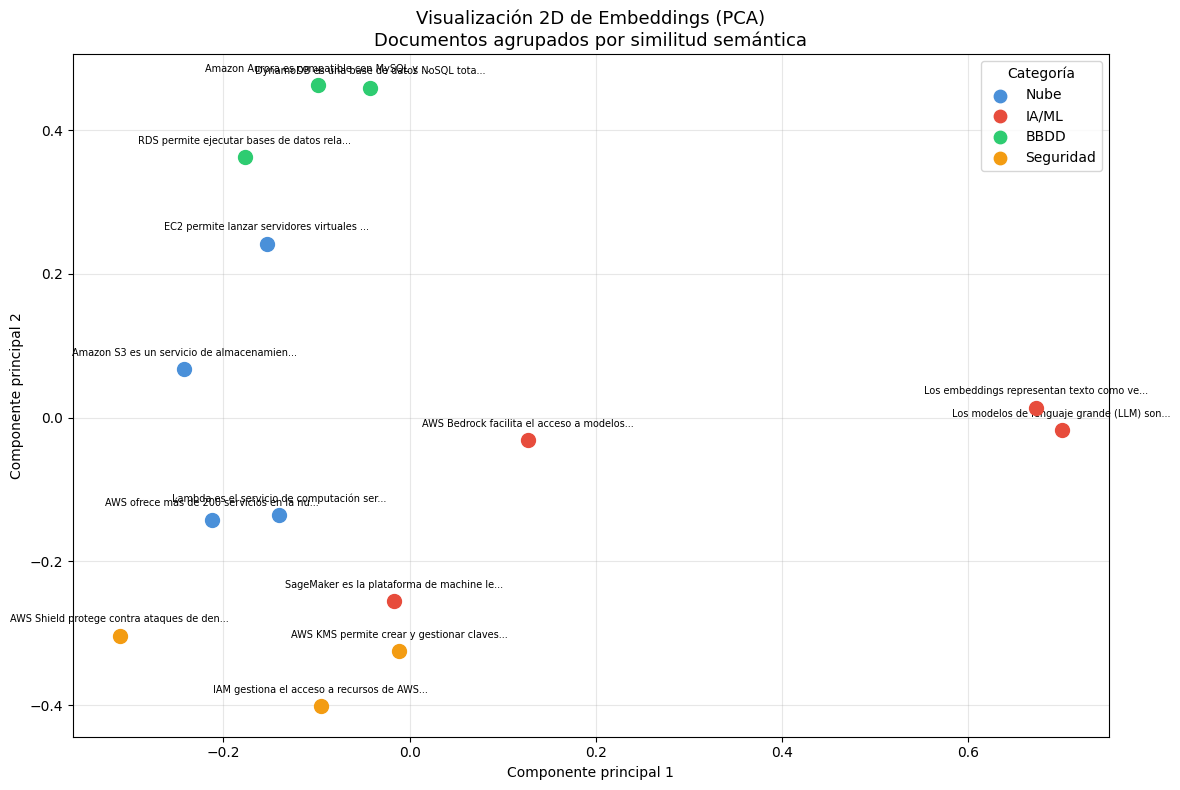

✅ Gráfico guardado como embeddings_2d.png


In [ ]:
try:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    # Etiquetas y colores por categoría
    categorias = (
        ["Nube"] * 4 +
        ["IA/ML"] * 4 +
        ["BBDD"] * 3 +
        ["Seguridad"] * 3
    )
    colores_map = {"Nube": "#4A90D9", "IA/ML": "#E74C3C", "BBDD": "#2ECC71", "Seguridad": "#F39C12"}

    # Reducción PCA a 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(matriz_embeddings)

    # Gráfico
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, (x, y) in enumerate(coords):
        cat = categorias[i]
        color = colores_map[cat]
        ax.scatter(x, y, c=color, s=100, zorder=3)
        label = documentos[i][:40] + "..."
        ax.annotate(label, (x, y), fontsize=7, ha="center", va="bottom",
                    xytext=(0, 8), textcoords="offset points")

    # Leyenda
    for cat, color in colores_map.items():
        ax.scatter([], [], c=color, label=cat, s=80)
    ax.legend(title="Categoría", loc="upper right")

    ax.set_title("Visualización 2D de Embeddings (PCA)\nDocumentos agrupados por similitud semántica", fontsize=13)
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("embeddings_2d.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Gráfico guardado como embeddings_2d.png")

except ImportError:
    print("Para visualización instala: pip install matplotlib scikit-learn")

## 11. Resumen y próximos pasos

En este notebook aprendiste a:

✅ Generar embeddings con **Amazon Titan Embeddings** vía Bedrock  
✅ Calcular **similitud coseno** entre textos  
✅ Construir un **índice vectorial con FAISS**  
✅ Realizar búsquedas semánticas eficientes  
✅ Comparar búsqueda semántica vs keywords  
✅ Persistir y cargar índices vectoriales  
✅ Visualizar embeddings con PCA  

### ¿Para qué sirve esto en producción?

| Caso de uso | Descripción |
|-------------|-------------|
| **RAG** | Recuperar contexto relevante para enriquecer prompts |
| **Buscadores** | Búsqueda semántica en documentación o catálogos |
| **Recomendaciones** | Encontrar contenido similar al que el usuario consume |
| **Deduplicación** | Detectar documentos casi idénticos en grandes colecciones |

---

**Siguiente notebook →** RAG (Retrieval-Augmented Generation) básico con Bedrock